In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.base import clone
import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Dados de entradas para o Early Stopping
M = 100
degree = 30
n_epochs = 1000
np.random.seed(42)

x = np.random.uniform(-3, 3, (M, 1))
n = np.random.normal(0, 1, (M,1))
y = 2 + x + 0.5*x**2 + x**3

y_noisy = y + n 

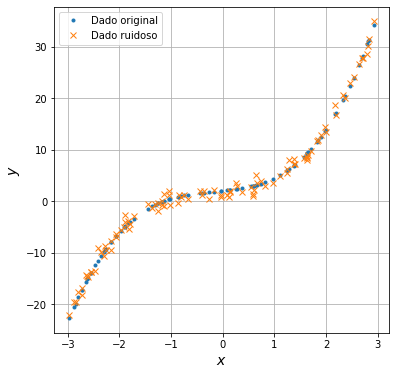

In [3]:
# Plot original data versus noisy version.
fig = plt.figure(figsize=(6,6))
plt.plot(x, y, '.', label='Dado original')
plt.plot(x, y_noisy, 'x', label='Dado ruidoso')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
#Show the plot.
plt.show()

## Batch gradient descent solution

In [4]:
"""
Batch gradient descent solution.
"""
def batchGradientDescent(Xb_train, Xb_test, y_train, y_test, degree, alpha, n_epochs, a):
    Jgd_treino = np.zeros(n_epochs+1)
    Jgd_test = np.zeros(n_epochs+1)
    minimum_val_error = float("inf")
    M_treino = len(y_train)
    M_test = len(y_test)
        
    Jgd_treino[0] = (1/M_treino)*sum(np.power((y_train - Xb_train.dot(a)) , 2))
    Jgd_test[0]   = (1/M_test)*sum(np.power((y_test - Xb_test.dot(a)) , 2))
    
    # Batch gradient-descent loop.
    iteration = 0
    error = 1
    
    while iteration < n_epochs:
        gradients = -2/len(y_train) * Xb_train.T.dot(y_train - Xb_train.dot(a))
        a = a - alpha * gradients
        Jgd_treino[iteration+1] = (1/M_treino)*sum(np.power((y_train - Xb_train.dot(a)) , 2))
        Jgd_test[iteration+1]   = (1/M_test)*sum(np.power((y_test - Xb_test.dot(a)) , 2))
        if Jgd_test[iteration+1] < minimum_val_error:
            minimum_val_error = Jgd_test[iteration+1]
            best_model = a
            
        iteration = iteration + 1
    
    return Jgd_treino, Jgd_test, a

## Validação: Train_test_split (70/30%)

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y_noisy, test_size=0.3, random_state=10)

# matriz de uns para o treinamento
Xb_train = np.ones((len(y_train),1))
for i in range(1, degree+1):
    # concatenação da matriz de uns com o X** de expoentes de 1 a 30
    Xb_train = np.c_[Xb_train, np.power(x_train,i)]
    
scaler = StandardScaler()
Xb_train = np.c_[np.ones((len(y_train),1)), scaler.fit_transform(Xb_train[:,1:])]

# matriz de uns para a validação
Xb_test = np.ones((len(y_test),1))
for i in range(1, degree+1):
      # concatenação da matriz de uns com o X** de expoentes de 1 a 30
    Xb_test = np.c_[Xb_test, np.power(x_test,i)]
    
scaler = StandardScaler()
Xb_test = np.c_[np.ones((len(y_test),1)), scaler.fit_transform(Xb_test[:,1:])]

a = np.random.randn(degree+1, 1)
alpha = 0.04

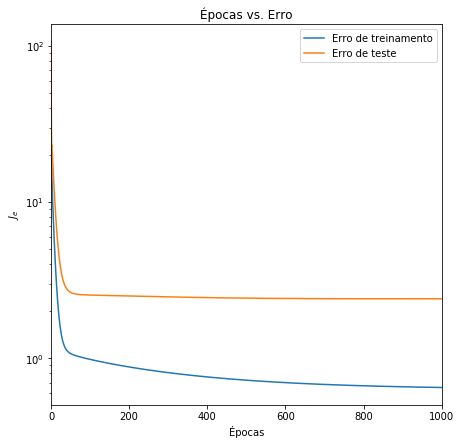

In [6]:
Jgd_treino, Jgd_test, a = batchGradientDescent(Xb_train, Xb_test, y_train, y_test, degree, alpha, n_epochs, a)

# Plot results.
fig = plt.figure(figsize=(7,7))
plt.plot(np.arange(0, n_epochs), Jgd_treino[0:n_epochs], label='Erro de treinamento')
plt.plot(np.arange(0, n_epochs), Jgd_test[0:n_epochs], label='Erro de teste')
plt.xlim((0, n_epochs))
plt.yscale('log')
plt.xlabel('Épocas')
plt.ylabel('$J_e$')
plt.title('Épocas vs. Erro')
plt.legend()
plt.show()

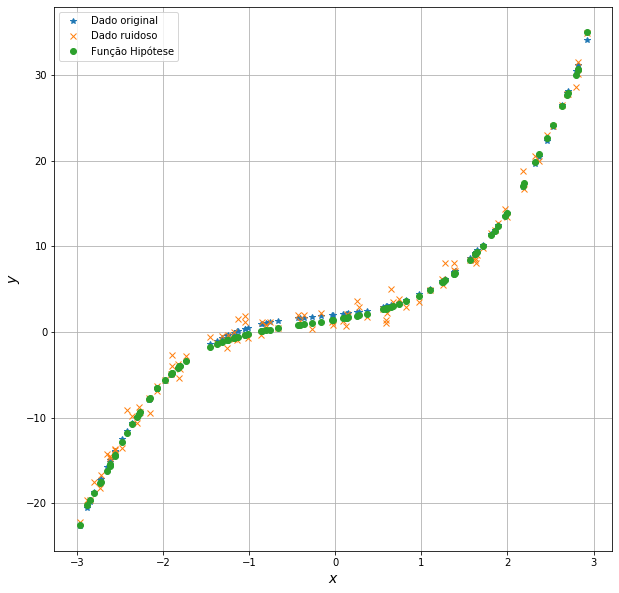

In [7]:
# matriz de uns para X inicial
Xb = np.ones((len(x),1))
for i in range(1, degree+1):
    # concatenação da matriz de uns com o X** de expoentes de 1 a 30
    Xb = np.c_[Xb, np.power(x,i)]
scaler = StandardScaler()
Xb = np.c_[np.ones((len(x),1)), scaler.fit_transform(Xb[:,1:])]

# Plot original data versus noisy version.
fig = plt.figure(figsize=(10,10))
plt.plot(x, y, '*', label='Dado original')
plt.plot(x, y_noisy, 'x', label='Dado ruidoso')
plt.plot(x, Xb.dot(a), 'o', label='Função Hipótese')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
#Show the plot.
plt.show()